Question 5 : Damped, Driven Harmonic Oscillator

In [1]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt

#defining the parameters
gamma = 0.5
w_0 = 2*np.pi
A_0 = 2.0
W = 2.0

x_0 = 1.0
v_0 = 0.0

t_start = 0.0
t_end = 30.0
step = 0.01

# defining the derivative function
def derivatives(t, x, v):
    dxdt = v
    dvdt = A_0*np.cos(W*t) - 2 * gamma * v - (w_0**2) * x
    return dxdt, dvdt

Implementing Euler Function

In [2]:
def euler(t_start, t_end, dt, x0, v0):
    n_steps = int((t_end - t_start) / dt) + 1
    t = np.linspace(t_start, t_end, n_steps)
    x = np.zeros(n_steps)
    v = np.zeros(n_steps)
    # setting initial conditions
    x[0] = x0
    v[0] = v0
    # performing Euler's method steps
    for i in range(n_steps - 1):
        # loading current state
        t_i = t[i]
        x_i = x[i]
        v_i = v[i]
        
        # calculating  derivatives at the current point
        dxdt, dvdt = derivatives(t_i, x_i, v_i)
        
        # updating next state using Euler's formula
        x[i+1] = x_i + dxdt * dt
        v[i+1] = v_i + dvdt * dt
        
    return t, x, v


Implementing RK4 method

In [3]:
def rk4(t_start, t_end, dt, x0, v0):    
    n_steps = int((t_end - t_start) / dt) + 1
    t = np.linspace(t_start, t_end, n_steps)
    x = np.zeros(n_steps)
    v = np.zeros(n_steps)
    # setting initial conditions
    x[0] = x0
    v[0] = v0
    # performing RK4 steps
    for i in range(n_steps - 1):
        # getting current state
        t_i = t[i]
        x_i = x[i]
        v_i = v[i]
        
        # calculating k1 slopes
        k1_x, k1_v = derivatives(t_i, x_i, v_i)
        
        # calculating k2 slopes
        k2_x, k2_v = derivatives(t_i + 0.5 * dt, x_i + 0.5 * k1_x * dt, v_i + 0.5 * k1_v * dt) 
                                 
        # calculating k3 slopes
        k3_x, k3_v = derivatives(t_i + 0.5 * dt, x_i + 0.5 * k2_x * dt, v_i + 0.5 * k2_v * dt)
                                  
        # calculating k4 slopes
        k4_x, k4_v = derivatives(t_i + dt, x_i + k3_x * dt, v_i + k3_v * dt)
                                  
        # combining slopes to get the final weighted average slope
        x_slope = (k1_x + 2*k2_x + 2*k3_x + k4_x) / 6.0
        v_slope = (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0
        
        # updating next state using RK4 formula
        x[i+1] = x_i + x_slope * dt
        v[i+1] = v_i + v_slope * dt
        
    return t, x, v

Part 1 : Getting the table

In [4]:
# function for printing the table
def print_table(name, t, x, v, step):
    print(f"\n--- {name} Method (dt = 0.01 s) ---")
    print("Tabulating every 500th time step:")
    print("-" * 50)
    print(f"{'Step':<10} | {'Time (s)':<12} | {'Displacement (m)':<18} | {'Velocity (m/s)':<18}")
    print("-" * 50)
    
    for i in range(0, len(t), step):
        print(f"{i:<10} | {t[i]:<12.2f} | {x[i]:<18.6f} | {v[i]:<18.6f}")
    print("-" * 50)

if __name__ == "__main__":    
    # solving using Euler's method
    t_euler, x_euler, v_euler = euler(t_start, t_end, step, x_0, v_0)
    
    # solving using RK4 method
    t_rk4, x_rk4, v_rk4 = rk4(t_start, t_end, step, x_0, v_0)
    
    # tabulating results
    TABULATION_STEP = 500
    print_table("Euler's", t_euler, x_euler, v_euler, TABULATION_STEP)
    print_table("RK4", t_rk4, x_rk4, v_rk4, TABULATION_STEP)    


--- Euler's Method (dt = 0.01 s) ---
Tabulating every 500th time step:
--------------------------------------------------
Step       | Time (s)     | Displacement (m)   | Velocity (m/s)    
--------------------------------------------------
0          | 0.00         | 1.000000           | 0.000000          
500        | 5.00         | 0.158295           | 0.034752          
1000       | 10.00        | 0.071181           | -0.110245         
1500       | 15.00        | 0.015637           | 0.108838          
2000       | 20.00        | -0.033052          | -0.088063         
2500       | 25.00        | 0.053948           | 0.034068          
3000       | 30.00        | -0.054385          | 0.029507          
--------------------------------------------------

--- RK4 Method (dt = 0.01 s) ---
Tabulating every 500th time step:
--------------------------------------------------
Step       | Time (s)     | Displacement (m)   | Velocity (m/s)    
--------------------------------------------

Part 2 : Visualization

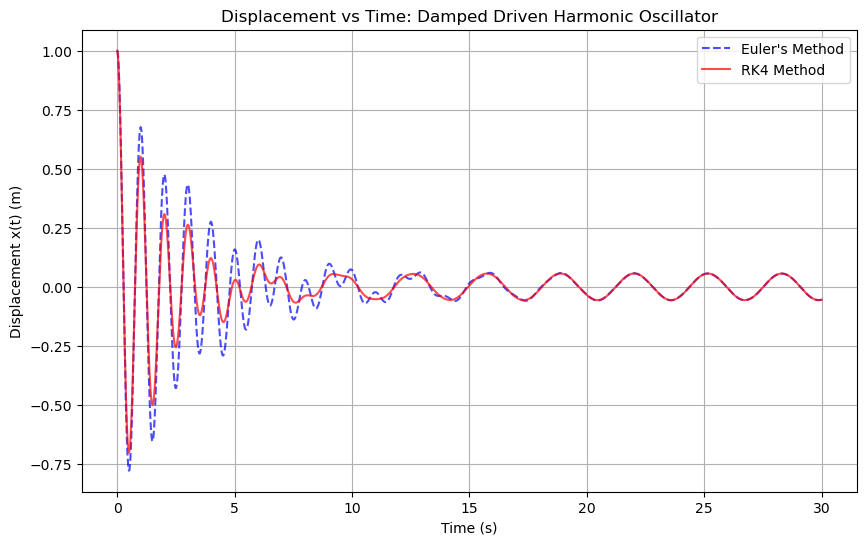

In [5]:
plt.figure(figsize=(10, 6))
    
# plotting Euler's method (dshed blue line)
plt.plot(t_euler, x_euler, label="Euler's Method", linestyle='--', color='blue', alpha=0.7)
    
# plotting RK4 method (solid red line)
plt.plot(t_rk4, x_rk4, label="RK4 Method", linestyle='-', color='red', alpha=0.7)
    
plt.title("Displacement vs Time: Damped Driven Harmonic Oscillator")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t) (m)")
plt.grid(True)
plt.legend()
plt.savefig("displacement_plot.png")
plt.show()

Part 3 : Analysis

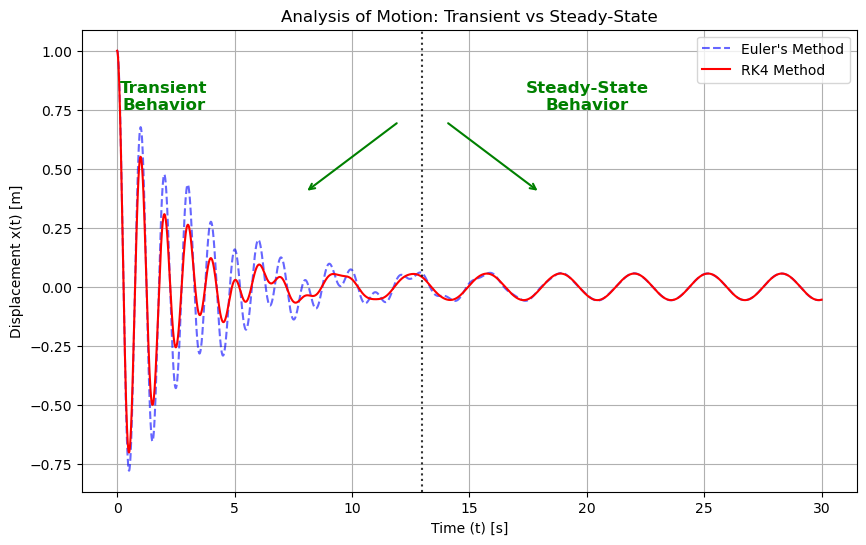

In [6]:

plt.figure(figsize=(10, 6))
plt.plot(t_euler, x_euler, label="Euler's Method", linestyle='--', color='blue', alpha=0.6)
plt.plot(t_rk4, x_rk4, label="RK4 Method", linestyle='-', color='red', linewidth=1.5)

# using t=13s for the separator
plt.axvline(x=13, color='black', linestyle=':', alpha=0.8)
plt.text(2, 0.75, "Transient\nBehavior", fontsize=12, color='green', fontweight='bold', ha='center')
plt.text(20, 0.75, "Steady-State\nBehavior", fontsize=12, color='green', fontweight='bold', ha='center')


plt.annotate('', xy=(18, 0.4), xytext=(14, 0.7), arrowprops=dict(arrowstyle='->', color='green', linewidth=1.5))
plt.annotate('', xy=(8, 0.4), xytext=(12, 0.7), arrowprops=dict(arrowstyle='->', color='green', linewidth=1.5))

plt.title("Analysis of Motion: Transient vs Steady-State")
plt.xlabel("Time (t) [s]")
plt.ylabel("Displacement x(t) [m]")
plt.grid(True)
plt.legend()
plt.savefig("displacement_analysis.png")
plt.show()

Part 4 : Convergence analysis

dt (s)     | Euler Error     | RK4 Error      
---------------------------------------------
0.0025     | 9.211967e-03    | 5.169448e-10   
0.005      | 2.004913e-02    | 8.796614e-09   
0.01       | 4.892623e-02    | 1.415439e-07   
0.02       | 1.907720e-01    | 2.274136e-06   
0.04       | 8.510231e+02    | 3.666689e-05   
0.08       | 8.414367e+11    | 5.950320e-04   

Euler Slope: 7.9990
RK4 Slope: 4.0216


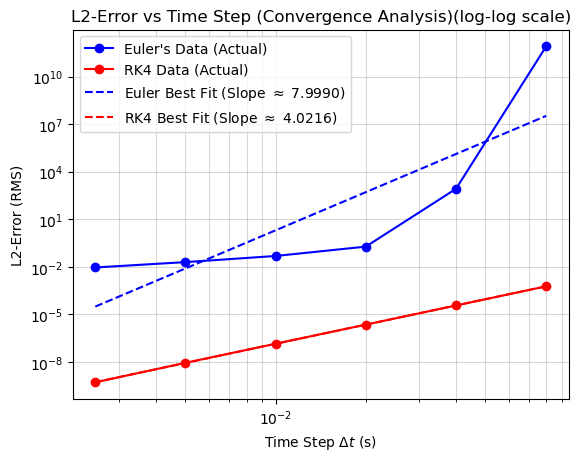

In [7]:

# function for mse error
def l2_error(t_test, x_test, t_true, x_true):
    # we need to compare points at same time so we will calculate ratio of steps (eg. true_dt = 0.00125 and test_dt = 0.0025, ratio = 2), rounding off to cover floating point inaccuracies
    ratio = int(round(len(t_true) / len(t_test)))
    #we take every ratio-th point from true solution 
    x_true_subset = x_true[::ratio]
    min_len = min(len(x_test), len(x_true_subset))
    x_test_trunc = x_test[:min_len]
    x_true_subset_trunc = x_true_subset[:min_len]
    # calculating rmse error
    error = np.sqrt(np.mean((x_test_trunc - x_true_subset_trunc)**2))
    return error

if __name__ == "__main__":
#generating true solution
    dt_true = 0.00125
    t_true, x_true, s = rk4(t_start, t_end, dt_true, x_0, v_0)

    #defining time steps
    dt_values = [0.0025, 0.005, 0.01, 0.02, 0.04, 0.08]
    euler_errors = []
    rk4_errors = []

    print(f"{'dt (s)':<10} | {'Euler Error':<15} | {'RK4 Error':<15}")
    print("-" * 45)

    for dt in dt_values:
        # running euler
        t_euler, x_euler, s_e = euler(t_start, t_end, dt, x_0, v_0)
        err_e = l2_error(t_euler, x_euler, t_true, x_true)
        euler_errors.append(err_e)
        
        # running RK4
        t_rk4, x_rk4, s_rk = rk4(t_start, t_end, dt, x_0, v_0)
        err_r = l2_error(t_rk4, x_rk4, t_true, x_true)
        rk4_errors.append(err_r)
        
        print(f"{dt:<10} | {err_e:<15.6e} | {err_r:<15.6e}")

   
    
    # plotting actual data (points)
    plt.loglog(dt_values, euler_errors, 'bo-', label="Euler's Data (Actual)")
    plt.loglog(dt_values, rk4_errors, 'ro-', label="RK4 Data (Actual)")
    
    # calculating best fit lines
    log_dt = np.log(dt_values)
    log_err_e = np.log(euler_errors)
    log_err_r = np.log(rk4_errors)    
    
    polyfit_euler = np.polyfit(log_dt, log_err_e, 1)
    slope_euler = polyfit_euler[0]

    polyfit_rk4 = np.polyfit(log_dt, log_err_r, 1)
    slope_rk4 = polyfit_rk4[0]

    print(f"\nEuler Slope: {slope_euler:.4f}")
    print(f"RK4 Slope: {slope_rk4:.4f}")
    
    fit_line_euler = np.exp(polyfit_euler[1] + polyfit_euler[0] * log_dt)
    fit_line_rk4 = np.exp(polyfit_rk4[1] + polyfit_rk4[0] * log_dt)

    # plotting best fit
    plt.loglog(dt_values, fit_line_euler, 'b--', 
               label=f"Euler Best Fit (Slope $\\approx$ {slope_euler:.4f})")
    plt.loglog(dt_values, fit_line_rk4, 'r--', 
               label=f"RK4 Best Fit (Slope $\\approx$ {slope_rk4:.4f})")
    
    plt.title("L2-Error vs Time Step (Convergence Analysis)(log-log scale)")
    plt.xlabel("Time Step $\Delta t$ (s)")
    plt.ylabel("L2-Error (RMS)")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    
    plt.savefig("convergence_plot.png")
    plt.show()

Stable Plot


Euler Slope: 1.4404
RK4 Slope: 4.0216


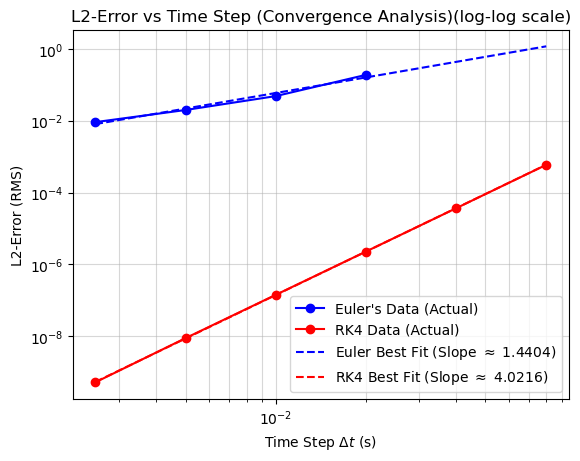

In [8]:
if __name__ == "__main__":    
    # plotting actual data (points)
    plt.loglog(dt_values[:4], euler_errors[:4], 'bo-', label="Euler's Data (Actual)")
    plt.loglog(dt_values, rk4_errors, 'ro-', label="RK4 Data (Actual)")
    
    # calculating best fit
    log_dt = np.log(dt_values)
    log_err_e = np.log(euler_errors)
    log_err_r = np.log(rk4_errors)    
    
    polyfit_euler = np.polyfit(log_dt[:4], log_err_e[:4], 1)
    slope_euler = polyfit_euler[0]

    polyfit_rk4 = np.polyfit(log_dt, log_err_r, 1)
    slope_rk4 = polyfit_rk4[0]

    print(f"\nEuler Slope: {slope_euler:.4f}")
    print(f"RK4 Slope: {slope_rk4:.4f}")
    
    fit_line_euler = np.exp(polyfit_euler[1] + polyfit_euler[0] * log_dt)
    fit_line_rk4 = np.exp(polyfit_rk4[1] + polyfit_rk4[0] * log_dt)

    # plotting best fit line
    plt.loglog(dt_values, fit_line_euler, 'b--', 
               label=f"Euler Best Fit (Slope $\\approx$ {slope_euler:.4f})")
    plt.loglog(dt_values, fit_line_rk4, 'r--', 
               label=f"RK4 Best Fit (Slope $\\approx$ {slope_rk4:.4f})")

    plt.title("L2-Error vs Time Step (Convergence Analysis)(log-log scale)")
    plt.xlabel("Time Step $\Delta t$ (s)")
    plt.ylabel("L2-Error (RMS)")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    
    plt.savefig("stable_convergence_plot.png")
    plt.show()